# Chapter 12: Trading Strategies Involving Options
## Trading Strategies, Spreads, and Combinations with Python

In this notebook, we explore the different trading strategies involving options as presented in **Chapter 12** of John Hull's *Options, Futures, and Other Derivatives*.

We will develop numerical frameworks and visualizations to replicate:
1. **Calendar Spreads**: Strategies involving options with different expiration dates.
2. **Diagonal Spreads**: Strategies where both the expiration date and the strike price of the calls are different.
3. **Combinations**: Taking a position in both calls and puts on the same stock (Straddles, Strips, Straps, and Strangles).
4. **Other Payoffs**: Approximating payoff functions using Butterfly Spreads.
5. **Practice Questions**: Fully solved with mathematical code and solutions positioned directly underneath each question.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Decimals formatted to cash precision
pd.options.display.float_format = '{:,.2f}'.format

# Elegant theme colors
navy_blue = '#1E3A8A'
emerald = '#10B981'
crimson = '#EF4444'
amber = '#F59E0B'
violet = '#8B5CF6'
dark_gray = '#374151'


---
## Spreads

A spread trading strategy involves taking a position in two or more options of the same type (i.e., two or more calls or two or more puts).

### Bull Spreads
A bull spread can be created by buying an option with a low strike price and selling an option with a higher strike price. This strategy is used when an investor expects the stock price to increase.
* **Using Calls**: Buy a call with strike $K_1$ and sell a call with strike $K_2$ ($K_2 > K_1$). This requires an initial investment because the lower strike call is more expensive.
* **Using Puts**: Buy a put with strike $K_1$ and sell a put with strike $K_2$ ($K_2 > K_1$). This generally results in an initial cash inflow.


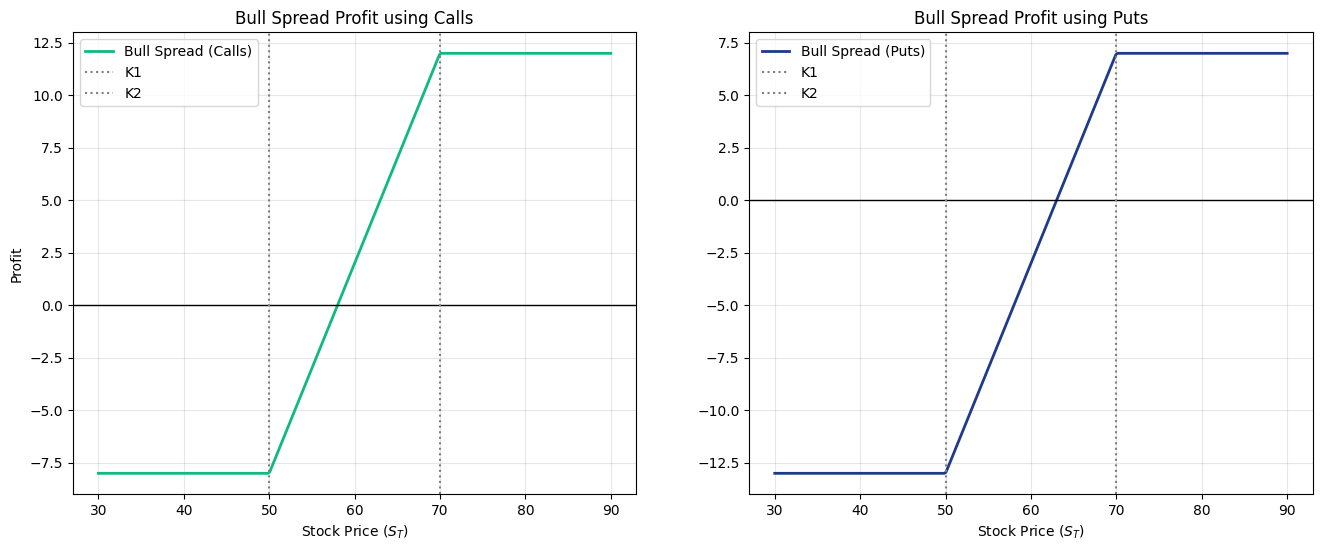

In [30]:
S_range_spreads = np.linspace(30, 90, 300)
K1_bull = 50; K2_bull = 70
call_p1 = 12; call_p2 = 4
put_p1 = 3; put_p2 = 10

# Bull Spread with Calls
payoff_long_call_bull = np.maximum(S_range_spreads - K1_bull, 0)
payoff_short_call_bull = -np.maximum(S_range_spreads - K2_bull, 0)
cost_bull_call = call_p1 - call_p2
profit_bull_call = payoff_long_call_bull + payoff_short_call_bull - cost_bull_call

# Bull Spread with Puts
payoff_long_put_bull = np.maximum(K1_bull - S_range_spreads, 0)
payoff_short_put_bull = -np.maximum(K2_bull - S_range_spreads, 0)
revenue_bull_put = put_p2 - put_p1  # Cash inflow
profit_bull_put = payoff_long_put_bull + payoff_short_put_bull + revenue_bull_put

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(S_range_spreads, profit_bull_call, color=emerald, lw=2, label='Bull Spread (Calls)')
axes[0].axhline(0, color='black', lw=1)
axes[0].axvline(K1_bull, color='gray', linestyle=':', label='K1')
axes[0].axvline(K2_bull, color='gray', linestyle=':', label='K2')
axes[0].set_title('Bull Spread Profit using Calls')
axes[0].set_xlabel('Stock Price ($S_T$)')
axes[0].set_ylabel('Profit')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(S_range_spreads, profit_bull_put, color=navy_blue, lw=2, label='Bull Spread (Puts)')
axes[1].axhline(0, color='black', lw=1)
axes[1].axvline(K1_bull, color='gray', linestyle=':', label='K1')
axes[1].axvline(K2_bull, color='gray', linestyle=':', label='K2')
axes[1].set_title('Bull Spread Profit using Puts')
axes[1].set_xlabel('Stock Price ($S_T$)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


### Bear Spreads
An investor who enters into a bear spread is hoping that the stock price will decline.
* **Using Puts**: Buy a put with a high strike price ($K_2$) and sell a put with a low strike price ($K_1$). Requires an initial investment.
* **Using Calls**: Buy a call with a high strike price ($K_2$) and sell a call with a low strike price ($K_1$). Results in an initial cash inflow.


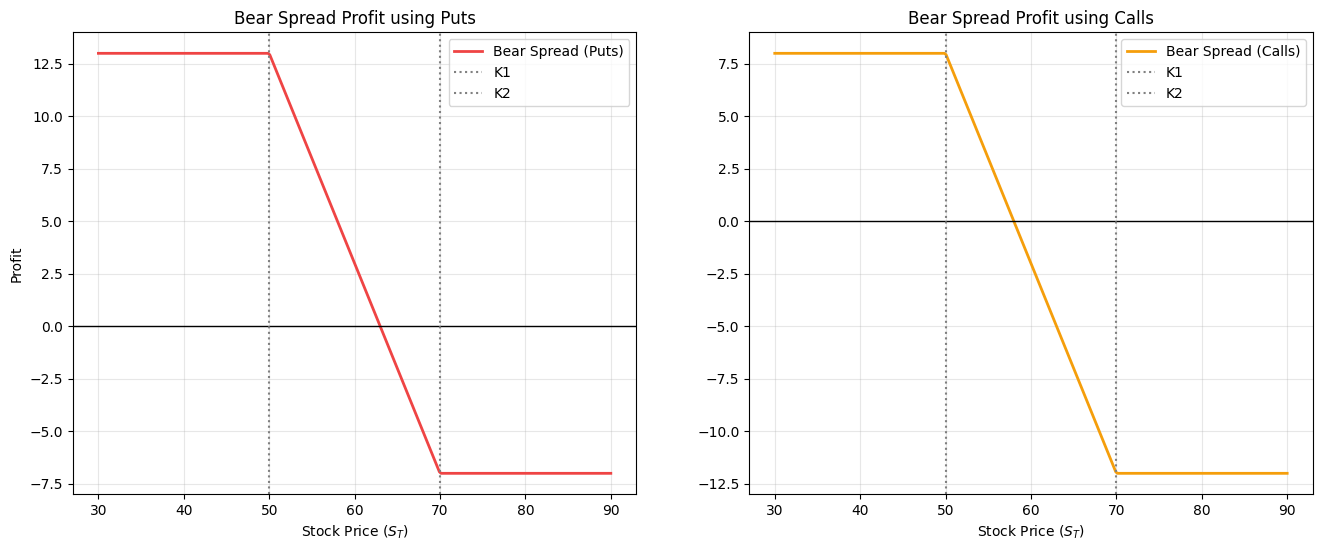

In [31]:
# Bear Spread with Puts
payoff_long_put_bear = np.maximum(K2_bull - S_range_spreads, 0)
payoff_short_put_bear = -np.maximum(K1_bull - S_range_spreads, 0)
cost_bear_put = put_p2 - put_p1
profit_bear_put = payoff_long_put_bear + payoff_short_put_bear - cost_bear_put

# Bear Spread with Calls
payoff_long_call_bear = np.maximum(S_range_spreads - K2_bull, 0)
payoff_short_call_bear = -np.maximum(S_range_spreads - K1_bull, 0)
revenue_bear_call = call_p1 - call_p2
profit_bear_call = payoff_long_call_bear + payoff_short_call_bear + revenue_bear_call

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(S_range_spreads, profit_bear_put, color=crimson, lw=2, label='Bear Spread (Puts)')
axes[0].axhline(0, color='black', lw=1)
axes[0].axvline(K1_bull, color='gray', linestyle=':', label='K1')
axes[0].axvline(K2_bull, color='gray', linestyle=':', label='K2')
axes[0].set_title('Bear Spread Profit using Puts')
axes[0].set_xlabel('Stock Price ($S_T$)')
axes[0].set_ylabel('Profit')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(S_range_spreads, profit_bear_call, color=amber, lw=2, label='Bear Spread (Calls)')
axes[1].axhline(0, color='black', lw=1)
axes[1].axvline(K1_bull, color='gray', linestyle=':', label='K1')
axes[1].axvline(K2_bull, color='gray', linestyle=':', label='K2')
axes[1].set_title('Bear Spread Profit using Calls')
axes[1].set_xlabel('Stock Price ($S_T$)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


### Box Spreads and Conversions (Simulating Fixed Income)

It is possible to use combinations of options (or options and the underlying asset) to simulate a fixed-income (risk-free) payoff.

1. **Box Spread (4 Options)**: A box spread is a combination of a bull call spread and a bear put spread with the same two strike prices ($K_1$ and $K_2$). The payoff is always exactly $K_2 - K_1$ regardless of the final stock price. Since the future payoff is known and risk-free, the initial cost of the box spread must be the present value of $K_2 - K_1$ discounted at the risk-free rate, otherwise there is an arbitrage opportunity.
2. **Conversion Strategy (3 Positions)**: A conversion involves a long position in the underlying stock, a long put, and a short call (where the put and call have the same strike price $K$ and expiration). By put-call parity, $S + P - C = K e^{-rT}$. The payoff at expiration is always precisely $K$, acting exactly like a risk-free bond.


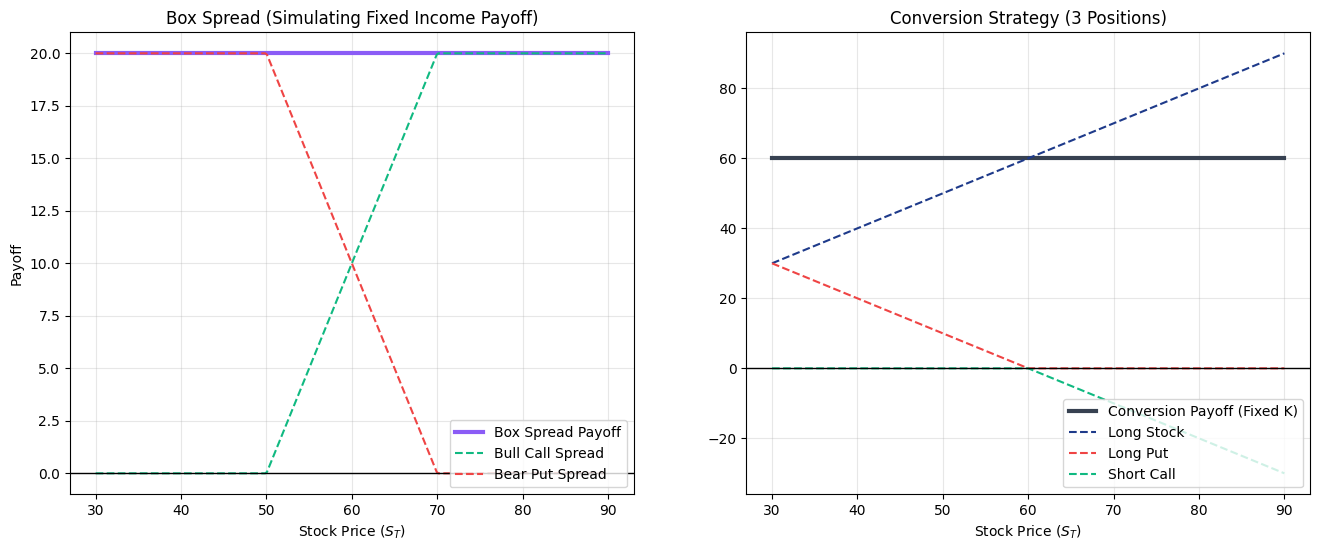

In [17]:
# Box Spread Payoff
payoff_bull_call = np.maximum(S_range_spreads - K1_bull, 0) - np.maximum(S_range_spreads - K2_bull, 0)
payoff_bear_put = np.maximum(K2_bull - S_range_spreads, 0) - np.maximum(K1_bull - S_range_spreads, 0)
payoff_box = payoff_bull_call + payoff_bear_put

# Conversion Payoff
payoff_stock = S_range_spreads
K_conv = 60
payoff_long_put_conv = np.maximum(K_conv - S_range_spreads, 0)
payoff_short_call_conv = -np.maximum(S_range_spreads - K_conv, 0)
payoff_conversion = payoff_stock + payoff_long_put_conv + payoff_short_call_conv

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Box Spread Payoff
axes[0].plot(S_range_spreads, payoff_box, color=violet, lw=3, label='Box Spread Payoff')
axes[0].plot(S_range_spreads, payoff_bull_call, '--', color=emerald, label='Bull Call Spread')
axes[0].plot(S_range_spreads, payoff_bear_put, '--', color=crimson, label='Bear Put Spread')
axes[0].axhline(0, color='black', lw=1)
axes[0].set_title('Box Spread (Simulating Fixed Income Payoff)')
axes[0].set_xlabel('Stock Price ($S_T$)')
axes[0].set_ylabel('Payoff')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='lower right')

# Plot Conversion Payoff
axes[1].plot(S_range_spreads, payoff_conversion, color=dark_gray, lw=3, label='Conversion Payoff (Fixed K)')
axes[1].plot(S_range_spreads, payoff_stock, '--', color=navy_blue, label='Long Stock')
axes[1].plot(S_range_spreads, payoff_long_put_conv, '--', color=crimson, label='Long Put')
axes[1].plot(S_range_spreads, payoff_short_call_conv, '--', color=emerald, label='Short Call')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Conversion Strategy (3 Positions)')
axes[1].set_xlabel('Stock Price ($S_T$)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='lower right')

plt.show()


---
## Calendar Spreads

In a neutral calendar spread, a strike price close to the current stock price is chosen.
A bullish calendar spread involves a higher strike price, whereas a bearish calendar spread involves a lower strike price.
Calendar spreads can be created with put options as well as call options. The investor buys a long-maturity put option and sells a short-maturity put option.

A reverse calendar spread is the opposite. The investor buys a short-maturity option and sells a long-maturity option.

*(Note: We can plot a profit pattern similar to calendar spreads. Because calendar spreads depend on the time value decay, their exact payoff at short-maturity expiration is a curve, not straight lines. We will simulate this using Black-Scholes for the long-maturity option).*


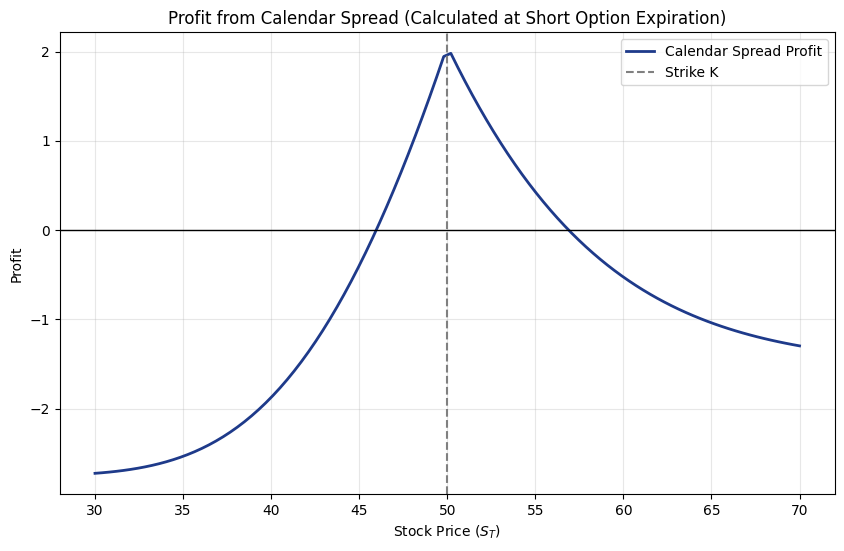

In [18]:
# Function to calculate Black-Scholes call/put prices to help with calendar spread payoffs
def black_scholes(S, K, T, r, sigma, option_type='call'):
    # Handle edge case where T is 0
    if T <= 0:
        if option_type == 'call':
            return np.maximum(S - K, 0)
        else:
            return np.maximum(K - S, 0)
            
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

S_range = np.linspace(30, 70, 100)
K = 50
T1 = 0  # Short maturity option expires today
T2 = 0.5 # Long maturity option expires in 6 months
r = 0.05
sigma = 0.3

# Neutral Calendar Spread using calls
# Sell short-maturity call, buy long-maturity call
# At T1 (today), the short call payoff is -max(S - K, 0)
# The long call value is its BS price with T=0.5
short_call_payoff = -np.maximum(S_range - K, 0)
long_call_value = black_scholes(S_range, K, T2, r, sigma, 'call')

# Assume initial cost: we paid for long call at S0=50, received for short call at S0=50
long_call_cost = black_scholes(50, K, T2+0.25, r, sigma, 'call')
short_call_revenue = black_scholes(50, K, 0.25, r, sigma, 'call')
initial_cost = long_call_cost - short_call_revenue

profit = short_call_payoff + long_call_value - initial_cost

plt.figure(figsize=(10, 6))
plt.plot(S_range, profit, color=navy_blue, lw=2, label='Calendar Spread Profit')
plt.axhline(0, color='black', lw=1)
plt.axvline(K, color='gray', linestyle='--', label='Strike K')
plt.title('Profit from Calendar Spread (Calculated at Short Option Expiration)')
plt.xlabel('Stock Price ($S_T$)')
plt.ylabel('Profit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Diagonal Spreads

Bull, bear, and calendar spreads can all be created from a long position in one call and a short position in another call. In the case of bull and bear spreads, the calls have different strike prices and the same expiration date. In the case of calendar spreads, the calls have the same strike price and different expiration dates.

In a diagonal spread both the expiration date and the strike price of the calls are different. This increases the range of profit patterns that are possible.


---
## Combinations

A combination is an option trading strategy that involves taking a position in both calls and puts on the same stock. We will consider straddles, strips, straps, and strangles.

### Straddle
One popular combination is a straddle, which involves buying a European call and put with the same strike price and expiration date. The strike price is denoted by $K$. If the stock price is close to this strike price at expiration of the options, the straddle leads to a loss. However, if there is a sufficiently large move in either direction, a significant profit will result.

| Range of stock price | Payoff from call | Payoff from put | Total payoff |
| :--- | :---: | :---: | :---: |
| $S_T \le K$ | 0 | $K - S_T$ | $K - S_T$ |
| $S_T > K$ | $S_T - K$ | 0 | $S_T - K$ |

A **top straddle** or straddle write is the reverse position. It is created by selling a call and a put with the same exercise price and expiration date. It is a highly risky strategy.


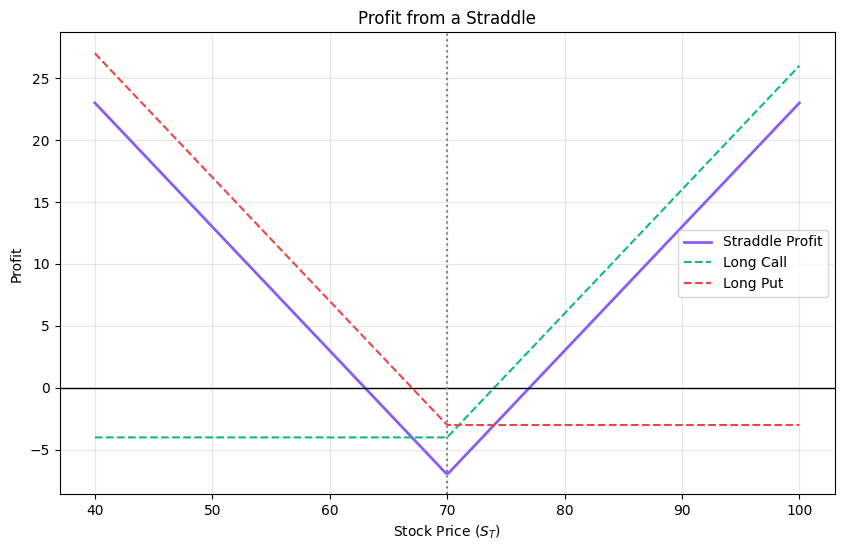

In [19]:
S_range_comb = np.linspace(40, 100, 300)
K_comb = 70
call_premium = 4
put_premium = 3
total_cost = call_premium + put_premium

# Long Straddle
payoff_call = np.maximum(S_range_comb - K_comb, 0)
payoff_put = np.maximum(K_comb - S_range_comb, 0)
profit_straddle = payoff_call + payoff_put - total_cost

plt.figure(figsize=(10, 6))
plt.plot(S_range_comb, profit_straddle, color=violet, lw=2, label='Straddle Profit')
plt.plot(S_range_comb, payoff_call - call_premium, '--', color=emerald, label='Long Call')
plt.plot(S_range_comb, payoff_put - put_premium, '--', color=crimson, label='Long Put')
plt.axhline(0, color='black', lw=1)
plt.axvline(K_comb, color='gray', linestyle=':')
plt.title('Profit from a Straddle')
plt.xlabel('Stock Price ($S_T$)')
plt.ylabel('Profit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Strips and Straps

* A **strip** consists of a long position in one European call and two European puts with the same strike price and expiration date. In a strip the investor is betting that there will be a big stock price move and considers a decrease in the stock price to be more likely than an increase.
* A **strap** consists of a long position in two European calls and one European put with the same strike price and expiration date. In a strap the investor is also betting that there will be a big stock price move. However, in this case, an increase in the stock price is considered to be more likely than a decrease.


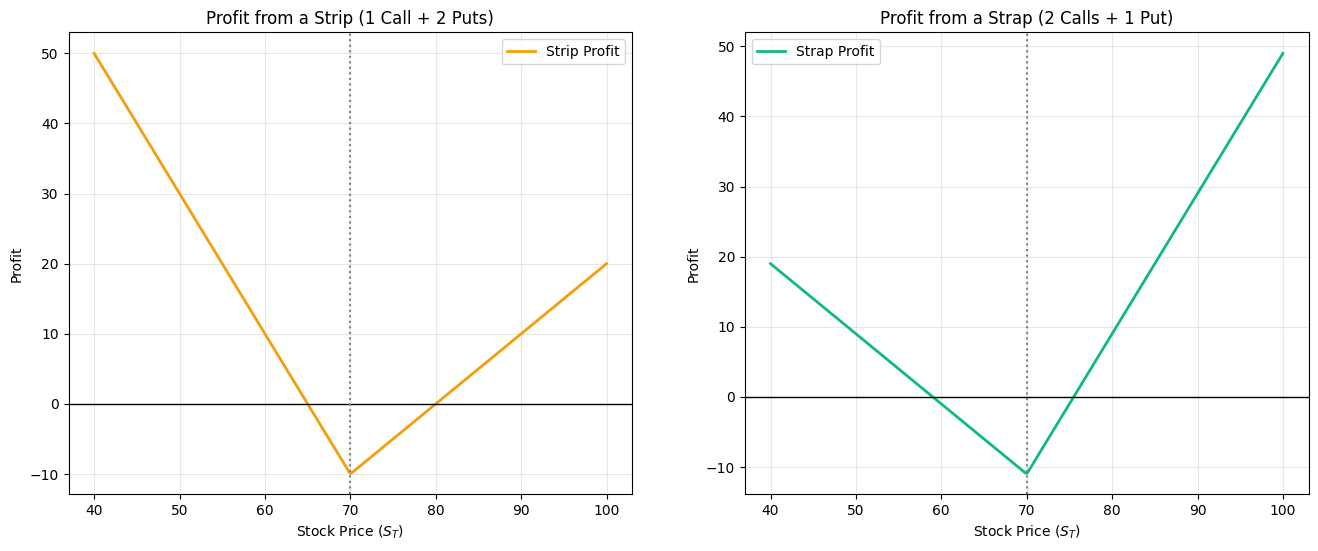

In [20]:
# Strip and Strap
cost_strip = call_premium + 2 * put_premium
cost_strap = 2 * call_premium + put_premium

profit_strip = payoff_call + 2 * payoff_put - cost_strip
profit_strap = 2 * payoff_call + payoff_put - cost_strap

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Strip
axes[0].plot(S_range_comb, profit_strip, color=amber, lw=2, label='Strip Profit')
axes[0].axhline(0, color='black', lw=1)
axes[0].axvline(K_comb, color='gray', linestyle=':')
axes[0].set_title('Profit from a Strip (1 Call + 2 Puts)')
axes[0].set_xlabel('Stock Price ($S_T$)')
axes[0].set_ylabel('Profit')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Strap
axes[1].plot(S_range_comb, profit_strap, color=emerald, lw=2, label='Strap Profit')
axes[1].axhline(0, color='black', lw=1)
axes[1].axvline(K_comb, color='gray', linestyle=':')
axes[1].set_title('Profit from a Strap (2 Calls + 1 Put)')
axes[1].set_xlabel('Stock Price ($S_T$)')
axes[1].set_ylabel('Profit')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()


### Strangles

In a strangle, sometimes called a bottom vertical combination, an investor buys a European put and a European call with the same expiration date and different strike prices. The call strike price, $K_2$, is higher than the put strike price, $K_1$.

| Range of stock price | Payoff from call | Payoff from put | Total payoff |
| :--- | :---: | :---: | :---: |
| $S_T \le K_1$ | 0 | $K_1 - S_T$ | $K_1 - S_T$ |
| $K_1 < S_T < K_2$ | 0 | 0 | 0 |
| $S_T \ge K_2$ | $S_T - K_2$ | 0 | $S_T - K_2$ |

A strangle is a similar strategy to a straddle. The investor is betting that there will be a large price move, but is uncertain whether it will be an increase or a decrease. The stock price has to move farther in a strangle than in a straddle for the investor to make a profit. However, the downside risk if the stock price ends up at a central value is less with a strangle.


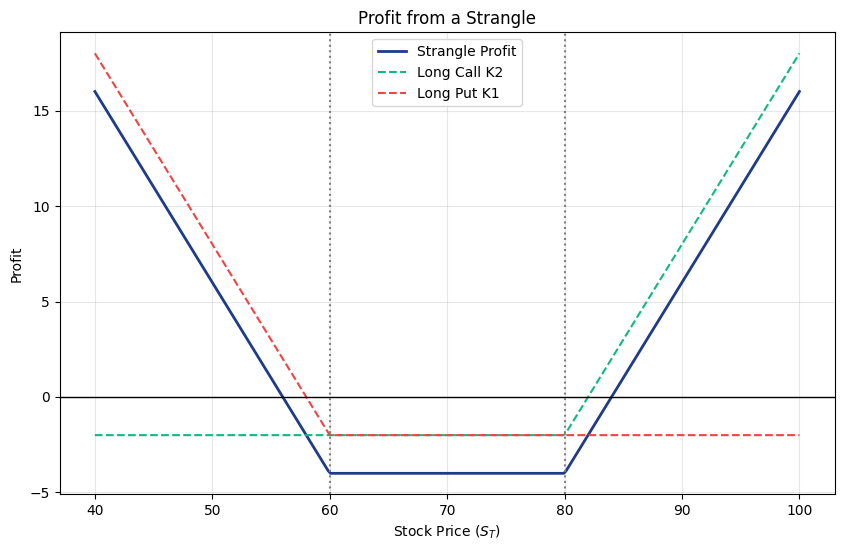

In [21]:
K1_strangle = 60
K2_strangle = 80
call_premium_strangle = 2
put_premium_strangle = 2
total_cost_strangle = call_premium_strangle + put_premium_strangle

payoff_call_strangle = np.maximum(S_range_comb - K2_strangle, 0)
payoff_put_strangle = np.maximum(K1_strangle - S_range_comb, 0)
profit_strangle_pos = payoff_call_strangle + payoff_put_strangle - total_cost_strangle

plt.figure(figsize=(10, 6))
plt.plot(S_range_comb, profit_strangle_pos, color=navy_blue, lw=2, label='Strangle Profit')
plt.plot(S_range_comb, payoff_call_strangle - call_premium_strangle, '--', color=emerald, label='Long Call K2')
plt.plot(S_range_comb, payoff_put_strangle - put_premium_strangle, '--', color=crimson, label='Long Put K1')
plt.axhline(0, color='black', lw=1)
plt.axvline(K1_strangle, color='gray', linestyle=':')
plt.axvline(K2_strangle, color='gray', linestyle=':')
plt.title('Profit from a Strangle')
plt.xlabel('Stock Price ($S_T$)')
plt.ylabel('Profit')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Other Payoffs

If European options expiring at time $T$ were available with every single possible strike price, any payoff function at time $T$ could in theory be obtained. The easiest illustration of this involves butterfly spreads.

Recall that a butterfly spread is created by buying options with strike prices $K_1$ and $K_3$ and selling two options with strike price $K_2$, where $K_1 < K_2 < K_3$ and $K_3 - K_2 = K_2 - K_1$. The pattern could be described as a spike. Through the judicious combination of a large number of very small spikes, any payoff function can in theory be approximated as accurately as desired.


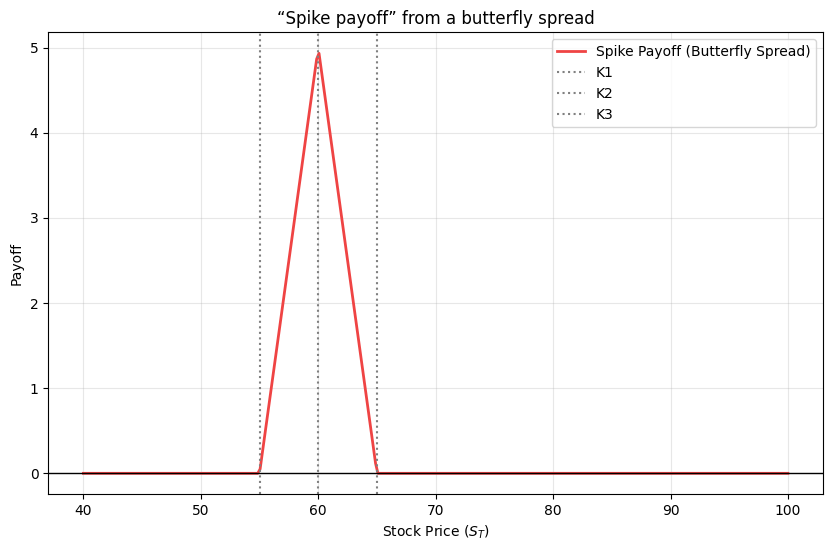

In [22]:
K1_bfly = 55
K2_bfly = 60
K3_bfly = 65

payoff_call1 = np.maximum(S_range_comb - K1_bfly, 0)
payoff_call2 = -2 * np.maximum(S_range_comb - K2_bfly, 0)
payoff_call3 = np.maximum(S_range_comb - K3_bfly, 0)

payoff_butterfly = payoff_call1 + payoff_call2 + payoff_call3

plt.figure(figsize=(10, 6))
plt.plot(S_range_comb, payoff_butterfly, color=crimson, lw=2, label='Spike Payoff (Butterfly Spread)')
plt.axhline(0, color='black', lw=1)
plt.axvline(K1_bfly, color='gray', linestyle=':', label='K1')
plt.axvline(K2_bfly, color='gray', linestyle=':', label='K2')
plt.axvline(K3_bfly, color='gray', linestyle=':', label='K3')
plt.title('“Spike payoff” from a butterfly spread')
plt.xlabel('Stock Price ($S_T$)')
plt.ylabel('Payoff')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


---
## Summary

* Principal-protected notes can be created from a zero-coupon bond and a European call option.
* A bull spread can be created by buying a call (put) with a low strike price and selling a call (put) with a high strike price. A bear spread is the opposite.
* A butterfly spread involves buying calls (puts) with a low and high strike price and selling two calls (puts) with some intermediate strike price.
* A calendar spread involves selling an option with a short time to expiration and buying an option with a longer time to expiration.
* A diagonal spread involves changing both strike price and expiration date.
* Combinations involve taking positions in both calls and puts on the same stock (Straddle, Strip, Strap, Strangle).
* Butterfly spreads can be used as building blocks to approximate any payoff function.


---
## Practice Questions

In this section, we will solve some of the practice questions of Chapter 12 using Python.


---
## Practice Question 12.1

### Question
Call options on a stock are available with strike prices of $15, $17.5, and $20, and expiration dates in 3 months. Their prices are $4, $2, and $0.5, respectively. Explain how the options can be used to create a butterfly spread. Construct a table showing how profit varies with stock price for the butterfly spread.

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


In [37]:
# Question 12.1 Solution
# Butterfly spread using Calls: Buy 1 Call at $15, Sell 2 Calls at $17.5, Buy 1 Call at $20.
K1_1 = 15; c1_1 = 4
K2_1 = 17.5; c2_1 = 2
K3_1 = 20; c3_1 = 0.5

initial_cost_1 = c1_1 + c3_1 - 2 * c2_1
print(f"Initial Cost of Butterfly Spread: ${initial_cost_1:.2f}")

S_scenarios = np.arange(15.0, 20.5, 0.5)
data_1 = []
for S in S_scenarios:
    payoff = max(S - K1_1, 0) - 2 * max(S - K2_1, 0) + max(S - K3_1, 0)
    profit = payoff - initial_cost_1
    data_1.append([S, payoff, profit])

df_12_1 = pd.DataFrame(data_1, columns=['Stock Price ($S_T$)', 'Payoff', 'Profit'])
display(df_12_1)


Initial Cost of Butterfly Spread: $0.50


,Stock Price ($S_T$),Payoff,Profit
0,15.00,0.00,-0.50
1,15.50,0.50,0.00
2,16.00,1.00,0.50
3,16.50,1.50,1.00
4,17.00,2.00,1.50
5,17.50,2.50,2.00
6,18.00,2.00,1.50
7,18.50,1.50,1.00
8,19.00,1.00,0.50
9,19.50,0.50,0.00


---
## Practice Question 12.2

### Question
A call option with a strike price of $50 costs $2. A put option with a strike price of $45 costs $3. Explain how a strangle can be created from these two options. What is the pattern of profits from the strangle?

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


In [43]:
# Question 12.2 Solution
# A strangle is created by buying both options (the put at $45 and the call at $50).
K_put_2 = 45; p_2 = 3
K_call_2 = 50; c_2 = 2
cost_2 = p_2 + c_2
print(f"Initial Cost of Strangle: ${cost_2:.2f}")

S_eval = np.arange(34, 62, 3)
data_strangle = []
for S in S_eval:
    payoff = max(K_put_2 - S, 0) + max(S - K_call_2, 0)
    profit = payoff - cost_2
    data_strangle.append([S, payoff, profit])

df_12_2 = pd.DataFrame(data_strangle, columns=['Stock Price', 'Payoff', 'Profit'])

print("\nProfit pattern: ")
display(df_12_2)
print("The investor makes a profit if S_T < $40 (since 45 - 5 = 40)")
print("or if S_T > $55 (since 50 + 5 = 55).")


Initial Cost of Strangle: $5.00

Profit pattern: 


,Stock Price,Payoff,Profit
0,34,11,6
1,37,8,3
2,40,5,0
3,43,2,-3
4,46,0,-5
5,49,0,-5
6,52,2,-3
7,55,5,0
8,58,8,3
9,61,11,6


The investor makes a profit if S_T < $40 (since 45 - 5 = 40)
or if S_T > $55 (since 50 + 5 = 55).


---
## Practice Question 12.16

### Question
A trader creates a bear spread by selling a 6-month put option with a $25 strike price for $2.15 and buying a 6-month put option with a $29 strike price for $4.75. What is the initial investment? What is the total payoff (excluding the initial investment) when the stock price in 6 months is (a) $23, (b) $28, and (c) $33.

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


In [25]:
# Question 12.16 Solution
K_low_16 = 25; p_low_16 = 2.15 # Sell
K_high_16 = 29; p_high_16 = 4.75 # Buy

initial_investment_16 = p_high_16 - p_low_16
print(f"Initial investment: ${initial_investment_16:.2f}")

scenarios_16 = [23, 28, 33]
for S in scenarios_16:
    payoff_buy = max(K_high_16 - S, 0)
    payoff_sell = -max(K_low_16 - S, 0)
    total_payoff = payoff_buy + payoff_sell
    print(f"Stock price ${S}: Total Payoff = ${total_payoff:.2f}")


Initial investment: $2.60
Stock price $23: Total Payoff = $4.00
Stock price $28: Total Payoff = $1.00
Stock price $33: Total Payoff = $0.00


---
## Practice Question 12.18

### Question
Three put options on a stock have the same expiration date and strike prices of $55, $60, and $65. The market prices are $3, $5, and $8, respectively. Explain how a butterfly spread can be created. Construct a table showing the profit from the strategy. For what range of stock prices would the butterfly spread lead to a loss?

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


In [44]:
# Question 12.18 Solution
# Butterfly spread using puts: Buy 1 put at $55, buy 1 put at $65, sell 2 puts at $60.
K1_18 = 55; p1_18 = 3
K2_18 = 60; p2_18 = 5
K3_18 = 65; p3_18 = 8

cost_bfly_18 = p1_18 + p3_18 - 2 * p2_18
print(f"Initial Cost of Butterfly Spread: ${cost_bfly_18:.2f}")

S_scenarios_18 =  np.arange(50, 80, 5)
data_12_18 = []
for S in S_scenarios_18:
    payoff = max(K1_18 - S, 0) + max(K3_18 - S, 0) - 2 * max(K2_18 - S, 0)
    profit = payoff - cost_bfly_18
    data_12_18.append([S, payoff, profit])

df_12_18 = pd.DataFrame(data_12_18, columns=['Stock Price', 'Payoff', 'Profit'])
display(df_12_18)
print("The butterfly spread leads to a loss if the profit is negative.")
print("This happens when S < 56 or S > 64.")


Initial Cost of Butterfly Spread: $1.00


,Stock Price,Payoff,Profit
0,50,0,-1
1,55,0,-1
2,60,5,4
3,65,0,-1
4,70,0,-1
5,75,0,-1


The butterfly spread leads to a loss if the profit is negative.
This happens when S < 56 or S > 64.


---
## Practice Question 12.19

### Question
A diagonal spread is created by buying a call with strike price K2 and exercise date T2 and selling a call with strike price K1 and exercise date T1, where T2 > T1. Draw a diagram showing the profit from the spread at time T1 when (a) K2 > K1 and (b) K2 < K1.

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


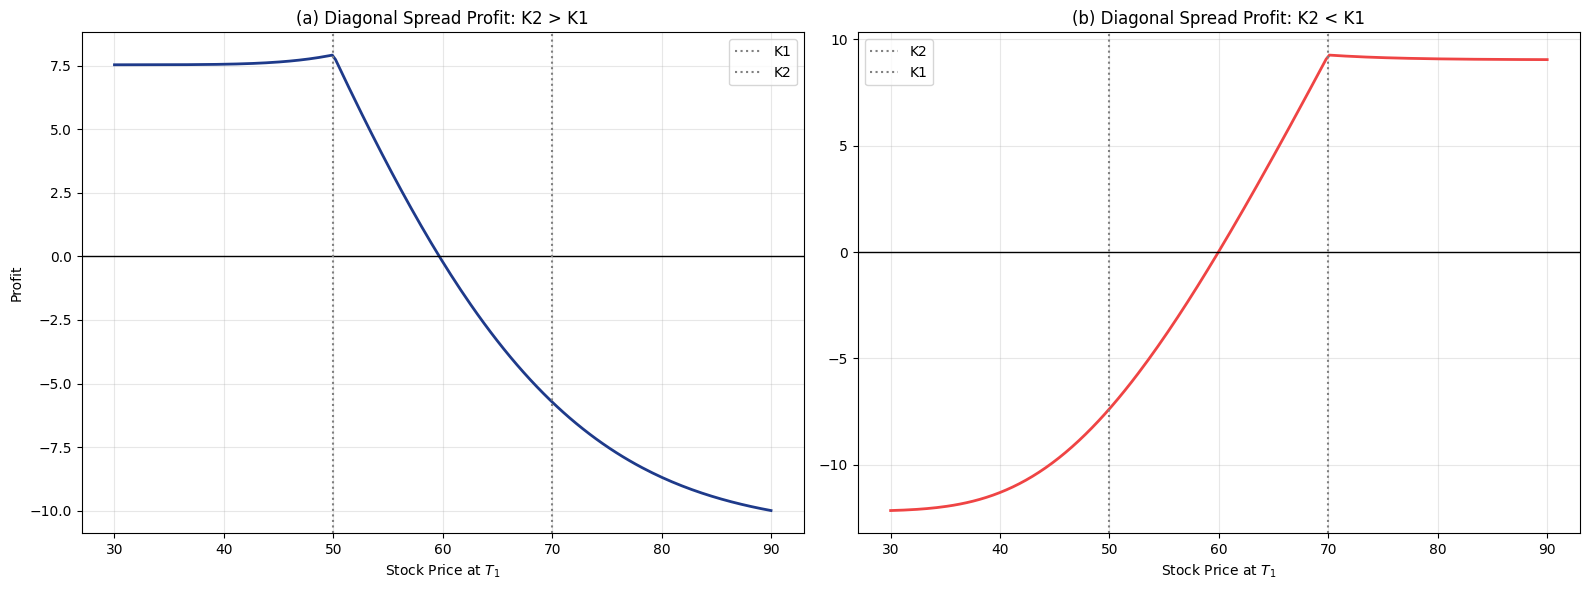

In [27]:
# Question 12.19 Solution
# To plot the diagonal spread profit at time T1, we note that the short call expires at T1, so its payoff is known: -max(S - K1, 0).
# The long call has time to expiration T2 - T1 remaining. We evaluate its value at T1 using Black-Scholes.

S_T1 = np.linspace(30, 90, 200)
r_19 = 0.05
sigma_19 = 0.30
T1_19 = 0.5
T2_19 = 1.0
S0_19 = 60 # Assume initial stock price

# (a) K2 > K1 (Bullish Diagonal Spread)
K1_a = 50; K2_a = 70
cost_long_a = black_scholes(S0_19, K2_a, T2_19, r_19, sigma_19, 'call')
revenue_short_a = black_scholes(S0_19, K1_a, T1_19, r_19, sigma_19, 'call')
net_cost_a = cost_long_a - revenue_short_a

value_long_T1_a = black_scholes(S_T1, K2_a, T2_19 - T1_19, r_19, sigma_19, 'call')
payoff_short_T1_a = -np.maximum(S_T1 - K1_a, 0)
profit_a = value_long_T1_a + payoff_short_T1_a - net_cost_a

# (b) K2 < K1 (Bearish Diagonal Spread)
K1_b = 70; K2_b = 50
cost_long_b = black_scholes(S0_19, K2_b, T2_19, r_19, sigma_19, 'call')
revenue_short_b = black_scholes(S0_19, K1_b, T1_19, r_19, sigma_19, 'call')
net_cost_b = cost_long_b - revenue_short_b

value_long_T1_b = black_scholes(S_T1, K2_b, T2_19 - T1_19, r_19, sigma_19, 'call')
payoff_short_T1_b = -np.maximum(S_T1 - K1_b, 0)
profit_b = value_long_T1_b + payoff_short_T1_b - net_cost_b

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(S_T1, profit_a, color=navy_blue, lw=2)
axes[0].axhline(0, color='black', lw=1)
axes[0].axvline(K1_a, color='gray', linestyle=':', label='K1')
axes[0].axvline(K2_a, color='gray', linestyle=':', label='K2')
axes[0].set_title('(a) Diagonal Spread Profit: K2 > K1')
axes[0].set_xlabel('Stock Price at $T_1$')
axes[0].set_ylabel('Profit')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(S_T1, profit_b, color=crimson, lw=2)
axes[1].axhline(0, color='black', lw=1)
axes[1].axvline(K2_b, color='gray', linestyle=':', label='K2')
axes[1].axvline(K1_b, color='gray', linestyle=':', label='K1')
axes[1].set_title('(b) Diagonal Spread Profit: K2 < K1')
axes[1].set_xlabel('Stock Price at $T_1$')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Practice Question 12.20

### Question
Draw a diagram showing the variation of an investor’s profit and loss with the terminal stock price for a portfolio consisting of : (a) One share and a short position in one call option (b) Two shares and a short position in one call option (c) One share and a short position in two call options (d) One share and a short position in four call options. In each case, assume that the call option has an exercise price equal to the current stock price.

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


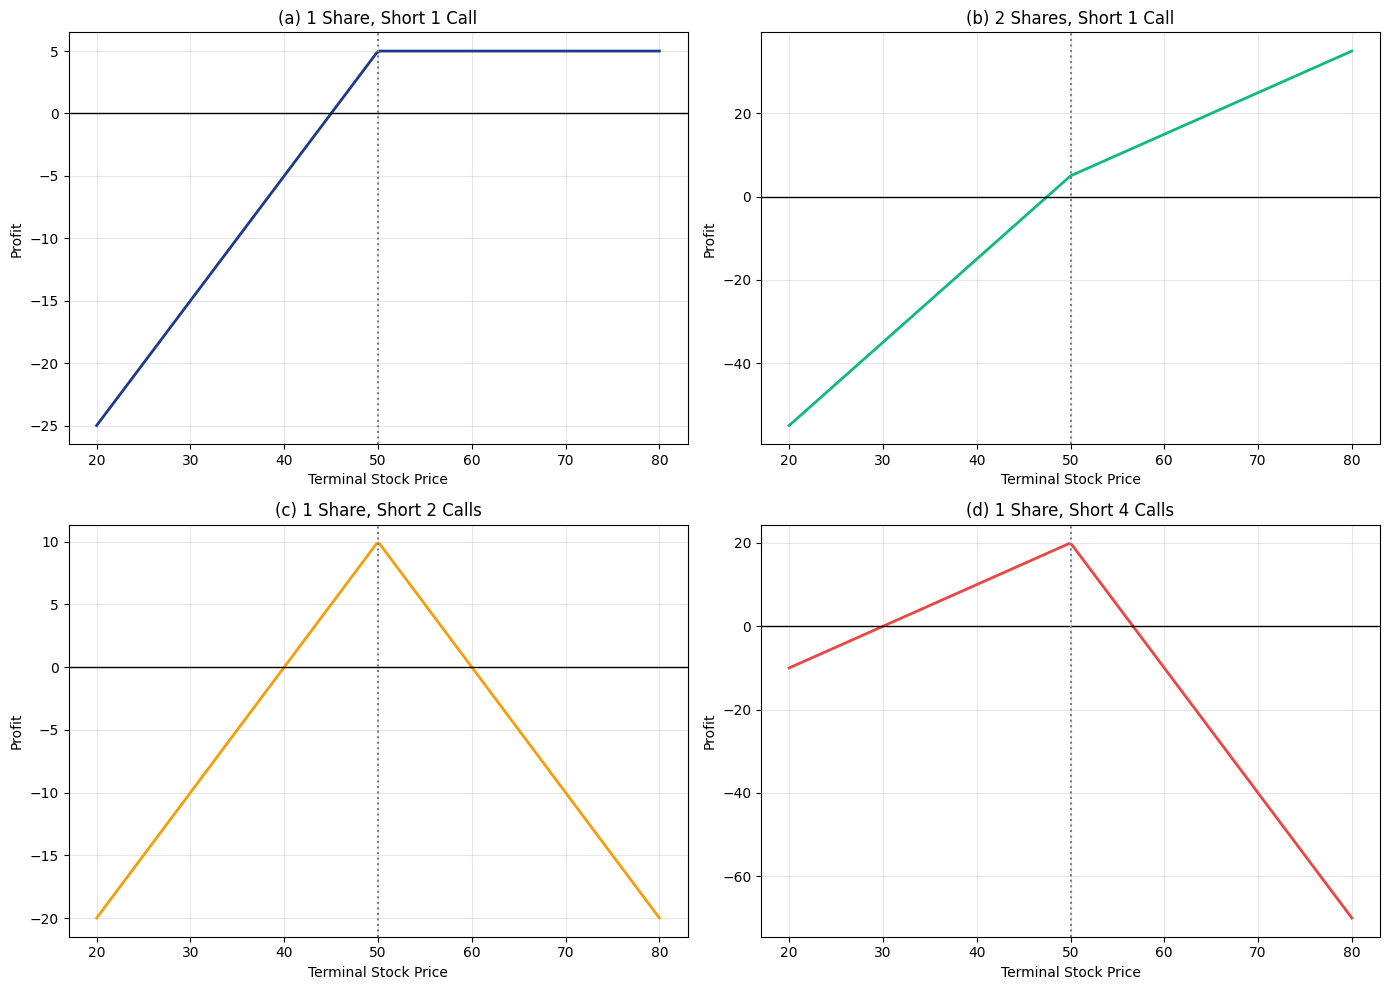

In [28]:
# Question 12.20 Solution
S0_20 = 50
K_20 = S0_20
S_T_20 = np.linspace(20, 80, 200)
call_premium_20 = 5

payoff_short_call = -np.maximum(S_T_20 - K_20, 0)

# (a) 1 share, short 1 call (Covered Call)
profit_a20 = (S_T_20 - S0_20) + (payoff_short_call + call_premium_20)

# (b) 2 shares, short 1 call
profit_b20 = 2 * (S_T_20 - S0_20) + (payoff_short_call + call_premium_20)

# (c) 1 share, short 2 calls (Ratio Write)
profit_c20 = (S_T_20 - S0_20) + 2 * (payoff_short_call + call_premium_20)

# (d) 1 share, short 4 calls
profit_d20 = (S_T_20 - S0_20) + 4 * (payoff_short_call + call_premium_20)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

ax1.plot(S_T_20, profit_a20, color=navy_blue, lw=2)
ax1.axhline(0, color='black', lw=1); ax1.axvline(K_20, color='gray', linestyle=':')
ax1.set_title('(a) 1 Share, Short 1 Call')

ax2.plot(S_T_20, profit_b20, color=emerald, lw=2)
ax2.axhline(0, color='black', lw=1); ax2.axvline(K_20, color='gray', linestyle=':')
ax2.set_title('(b) 2 Shares, Short 1 Call')

ax3.plot(S_T_20, profit_c20, color=amber, lw=2)
ax3.axhline(0, color='black', lw=1); ax3.axvline(K_20, color='gray', linestyle=':')
ax3.set_title('(c) 1 Share, Short 2 Calls')

ax4.plot(S_T_20, profit_d20, color=crimson, lw=2)
ax4.axhline(0, color='black', lw=1); ax4.axvline(K_20, color='gray', linestyle=':')
ax4.set_title('(d) 1 Share, Short 4 Calls')

for ax in (ax1, ax2, ax3, ax4):
    ax.set_xlabel('Terminal Stock Price')
    ax.set_ylabel('Profit')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Practice Question 12.21

### Question
Suppose that the price of a non-dividend-paying stock is $32, its volatility is 30%, and the risk-free rate for all maturities is 5% per annum. Use DerivaGem (or Black-Scholes) to calculate the cost of setting up the following positions... In each case provide a table showing the relationship between profit and final stock price. (We will also provide plots!)

### Solution
* Let's write Python code to implement the strategy and plot the payoff profile.


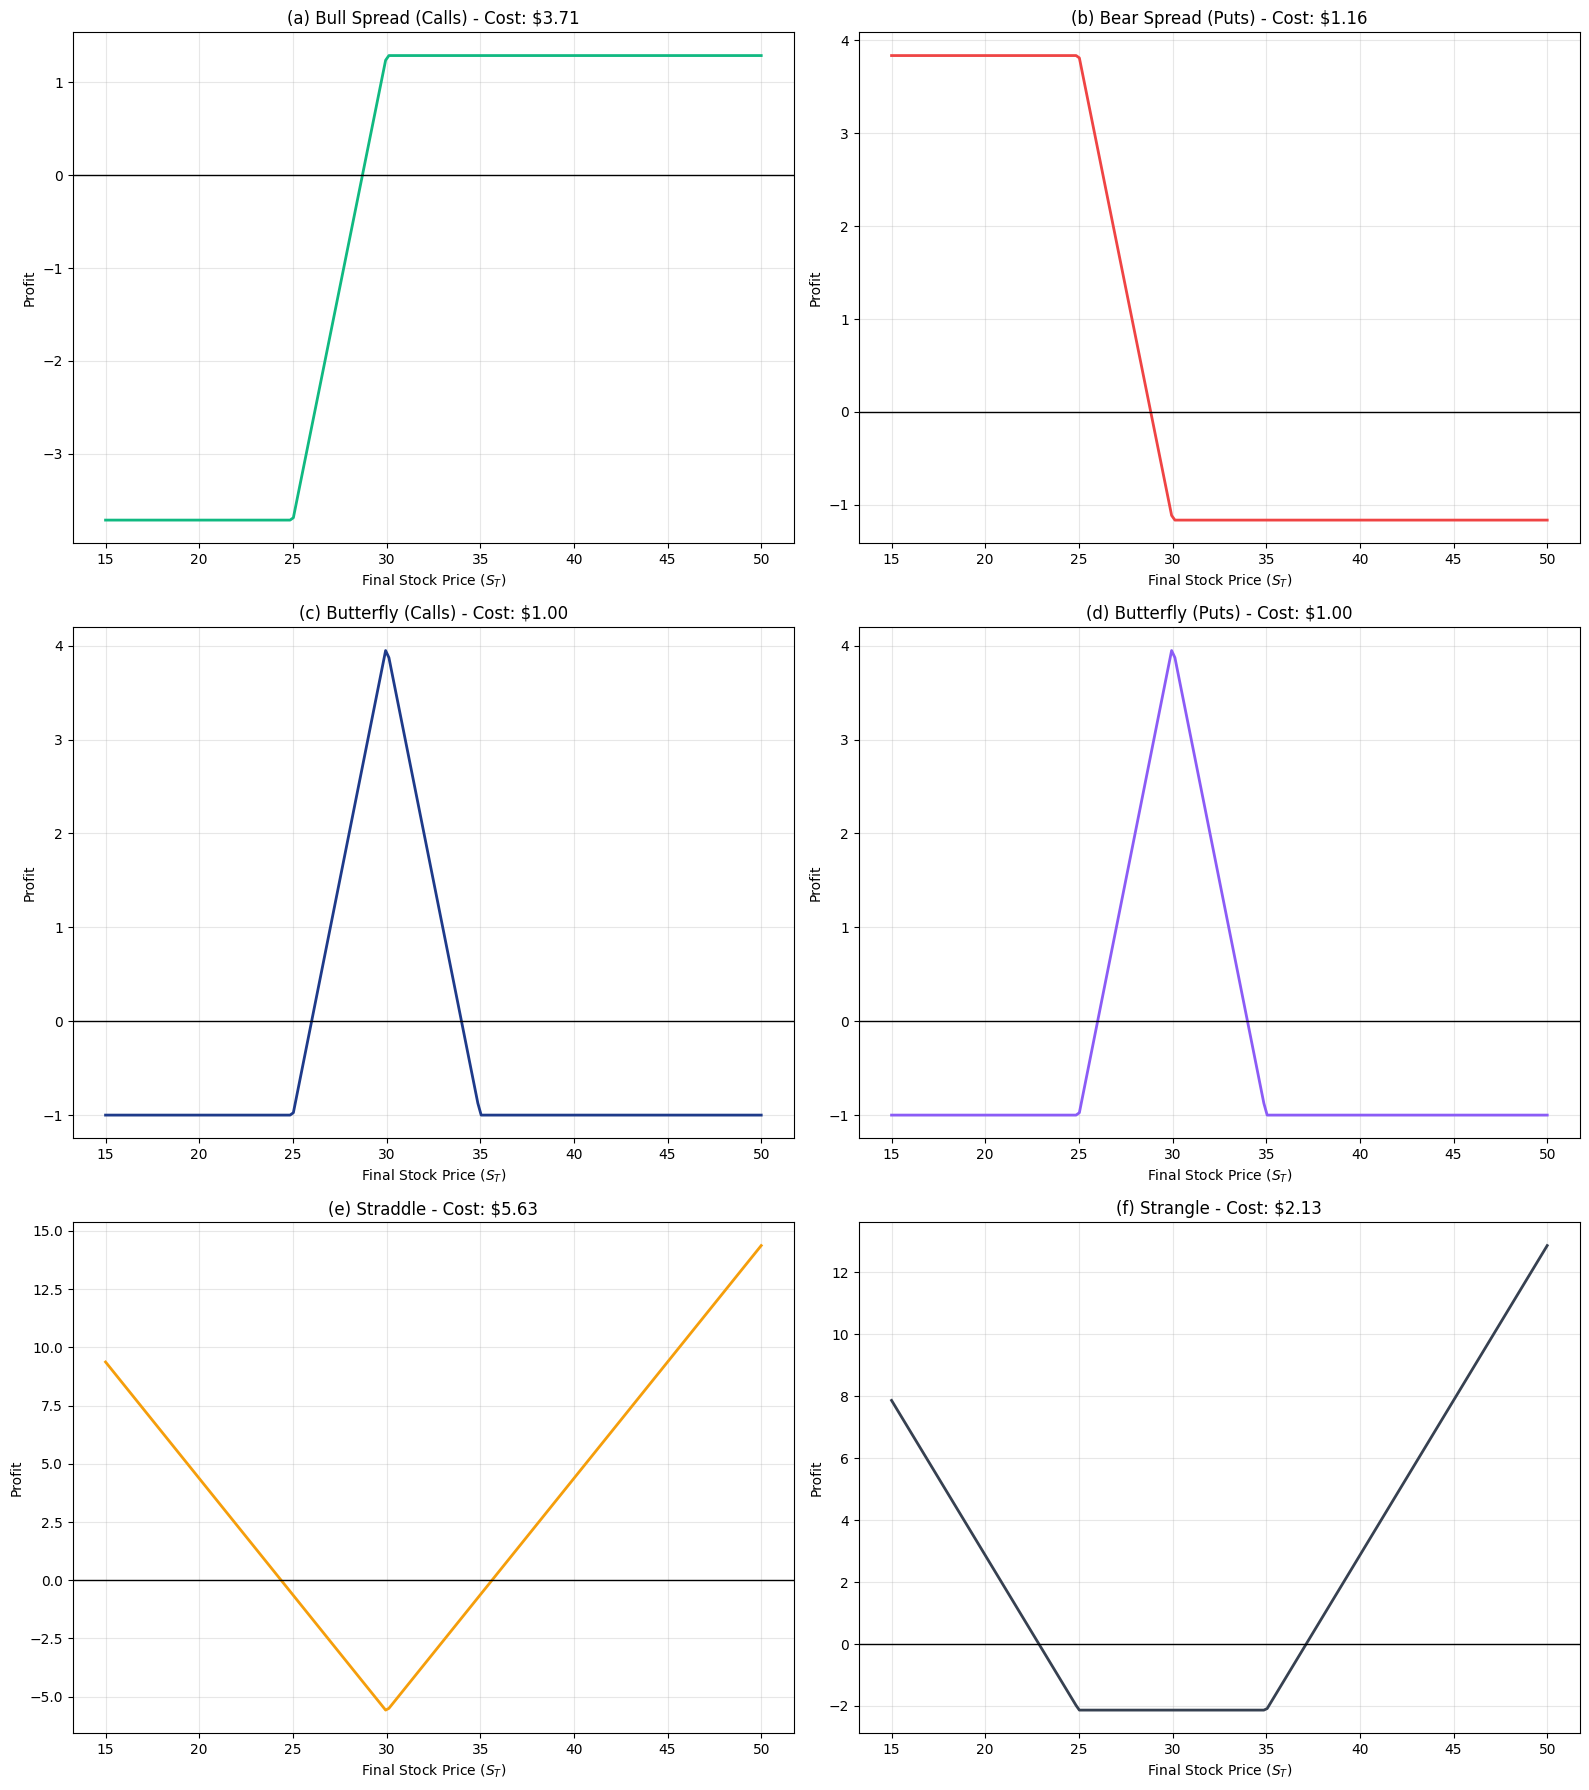

In [29]:
# Question 12.21 Solution
S0_21 = 32
sigma_21 = 0.30
r_21 = 0.05
S_eval_21 = np.linspace(15, 50, 200)

def plot_strategy_profit(ax, S_range, profit, title, color):
    ax.plot(S_range, profit, color=color, lw=2)
    ax.axhline(0, color='black', lw=1)
    ax.set_title(title)
    ax.set_xlabel('Final Stock Price ($S_T$)')
    ax.set_ylabel('Profit')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# (a) Bull spread using calls: K1=25, K2=30, T=0.5
c_25 = black_scholes(S0_21, 25, 0.5, r_21, sigma_21, 'call')
c_30 = black_scholes(S0_21, 30, 0.5, r_21, sigma_21, 'call')
bull_call_cost = c_25 - c_30
profit_a21 = np.maximum(S_eval_21 - 25, 0) - np.maximum(S_eval_21 - 30, 0) - bull_call_cost
plot_strategy_profit(axes[0], S_eval_21, profit_a21, f'(a) Bull Spread (Calls) - Cost: ${bull_call_cost:.2f}', emerald)

# (b) Bear spread using puts: K1=25, K2=30, T=0.5
p_25 = black_scholes(S0_21, 25, 0.5, r_21, sigma_21, 'put')
p_30 = black_scholes(S0_21, 30, 0.5, r_21, sigma_21, 'put')
bear_put_cost = p_30 - p_25
profit_b21 = np.maximum(30 - S_eval_21, 0) - np.maximum(25 - S_eval_21, 0) - bear_put_cost
plot_strategy_profit(axes[1], S_eval_21, profit_b21, f'(b) Bear Spread (Puts) - Cost: ${bear_put_cost:.2f}', crimson)

# (c) Butterfly spread using calls: K1=25, K2=30, K3=35, T=1.0
c_25_1 = black_scholes(S0_21, 25, 1.0, r_21, sigma_21, 'call')
c_30_1 = black_scholes(S0_21, 30, 1.0, r_21, sigma_21, 'call')
c_35_1 = black_scholes(S0_21, 35, 1.0, r_21, sigma_21, 'call')
bfly_call_cost = c_25_1 + c_35_1 - 2 * c_30_1
profit_c21 = np.maximum(S_eval_21 - 25, 0) + np.maximum(S_eval_21 - 35, 0) - 2 * np.maximum(S_eval_21 - 30, 0) - bfly_call_cost
plot_strategy_profit(axes[2], S_eval_21, profit_c21, f'(c) Butterfly (Calls) - Cost: ${bfly_call_cost:.2f}', navy_blue)

# (d) Butterfly spread using puts: K1=25, K2=30, K3=35, T=1.0
p_25_1 = black_scholes(S0_21, 25, 1.0, r_21, sigma_21, 'put')
p_30_1 = black_scholes(S0_21, 30, 1.0, r_21, sigma_21, 'put')
p_35_1 = black_scholes(S0_21, 35, 1.0, r_21, sigma_21, 'put')
bfly_put_cost = p_25_1 + p_35_1 - 2 * p_30_1
profit_d21 = np.maximum(25 - S_eval_21, 0) + np.maximum(35 - S_eval_21, 0) - 2 * np.maximum(30 - S_eval_21, 0) - bfly_put_cost
plot_strategy_profit(axes[3], S_eval_21, profit_d21, f'(d) Butterfly (Puts) - Cost: ${bfly_put_cost:.2f}', violet)

# (e) Straddle: K=30, T=0.5
straddle_cost = c_30 + p_30
profit_e21 = np.maximum(S_eval_21 - 30, 0) + np.maximum(30 - S_eval_21, 0) - straddle_cost
plot_strategy_profit(axes[4], S_eval_21, profit_e21, f'(e) Straddle - Cost: ${straddle_cost:.2f}', amber)

# (f) Strangle: K1=25, K2=35, T=0.5
c_35 = black_scholes(S0_21, 35, 0.5, r_21, sigma_21, 'call')
strangle_cost = p_25 + c_35
profit_f21 = np.maximum(25 - S_eval_21, 0) + np.maximum(S_eval_21 - 35, 0) - strangle_cost
plot_strategy_profit(axes[5], S_eval_21, profit_f21, f'(f) Strangle - Cost: ${strangle_cost:.2f}', dark_gray)

plt.tight_layout()
plt.show()
